 Veri seti başarıyla yüklendi: 740 satır, 21 sütun
Veri setinde boş/kayıp değer yok.


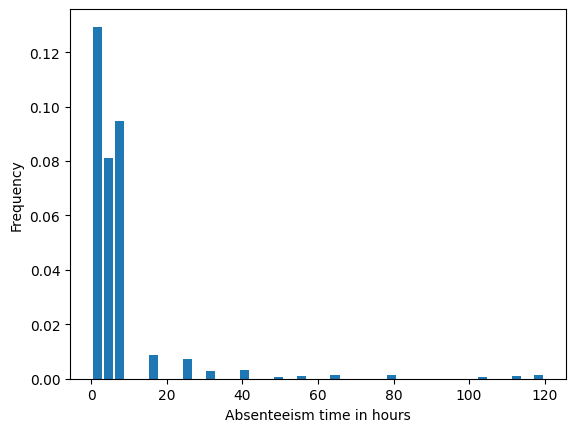

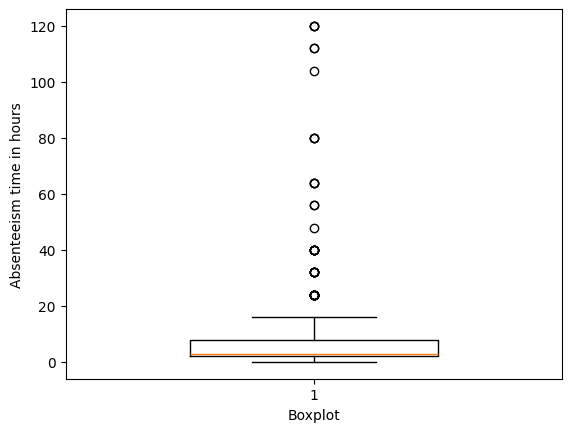

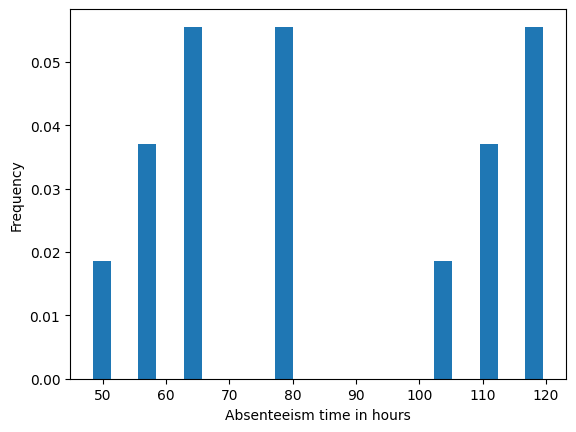

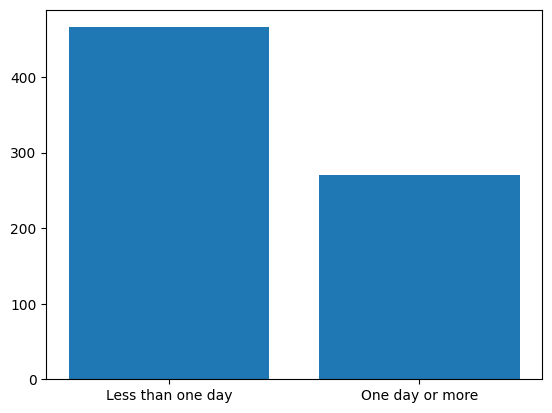

abs_lev,days,hours,late
reason_text,,,
Bilinmiyor / Mevcut değil,0,0,40
Tıbbi konsültasyon (Doktor görüşmesi),13,98,38
Diş muayenesi,8,76,28
Kas-iskelet sistemi ve bağ dokusu hastalıkları,38,11,6
Sindirim sistemi hastalıkları,14,7,5


abs_lev,days,hours,late
reason_text,,,
Tıbbi konsültasyon (Doktor görüşmesi),13,98,38
Diş muayenesi,8,76,28
Fizyoterapi,0,66,3
Laboratuvar muayenesi / tetkik,4,26,1
Kas-iskelet sistemi ve bağ dokusu hastalıkları,38,11,6


abs_lev,days,hours,late
reason_text,,,
Kas-iskelet sistemi ve bağ dokusu hastalıkları,38,11,6
Hasta takibi,34,4,0
"Yaralanma, zehirlenme ve dış etken sonuçları",33,6,1
Haksız/Gerekçesiz devamsızlık,25,8,0
Solunum sistemi hastalıkları,21,4,0


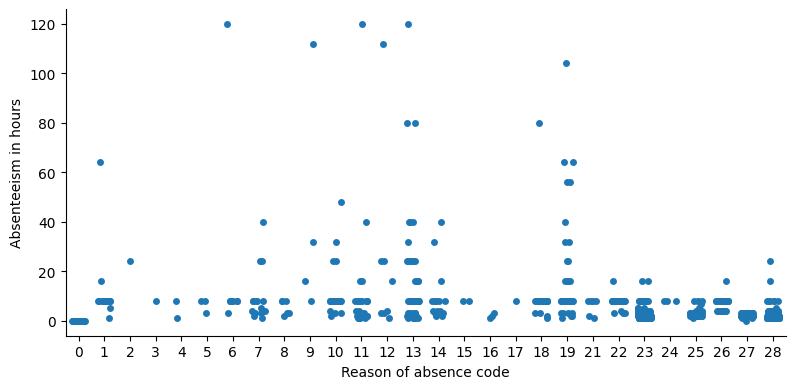

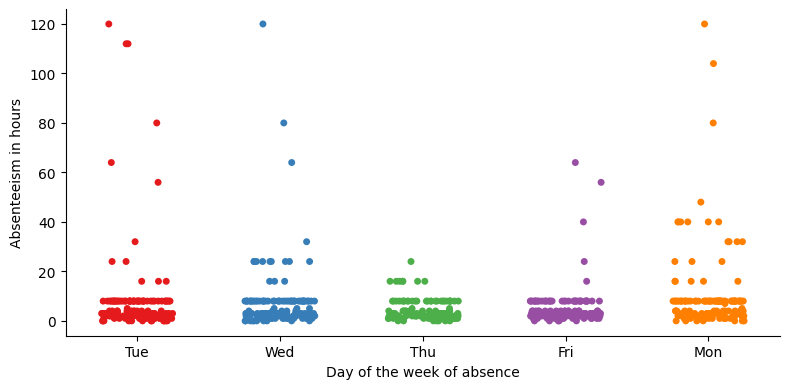

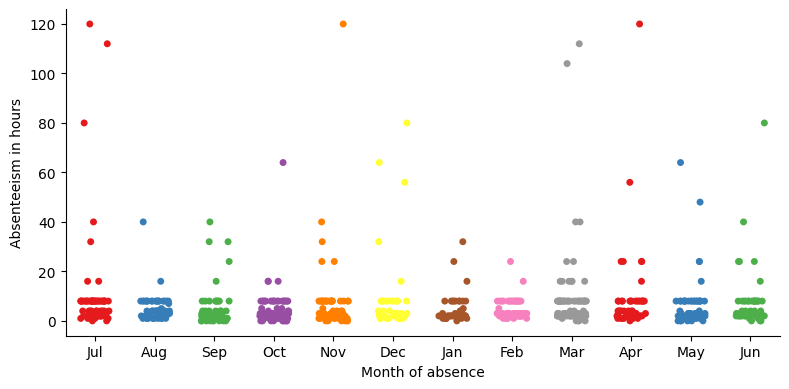

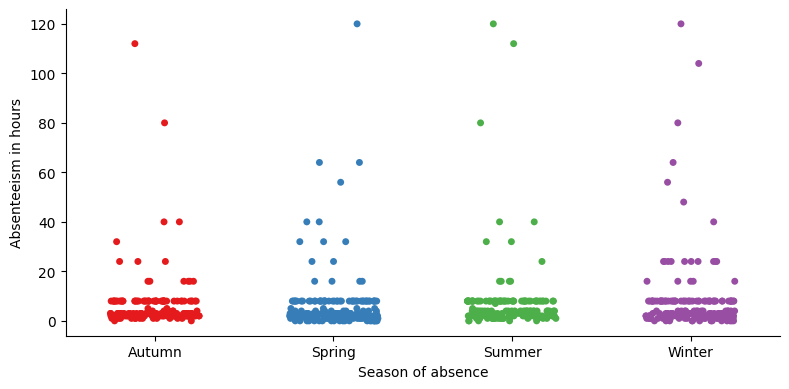

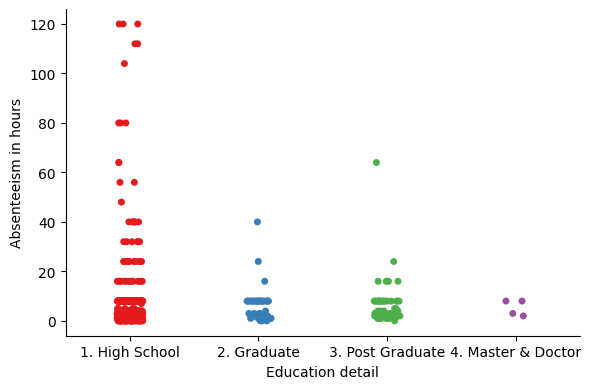

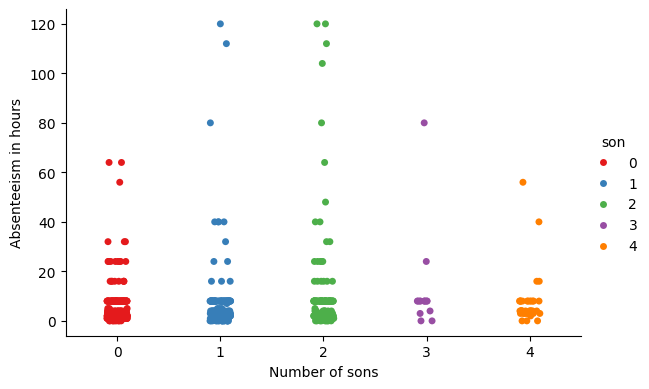

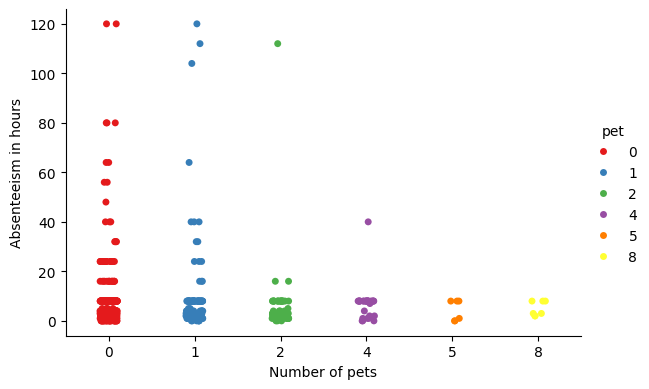

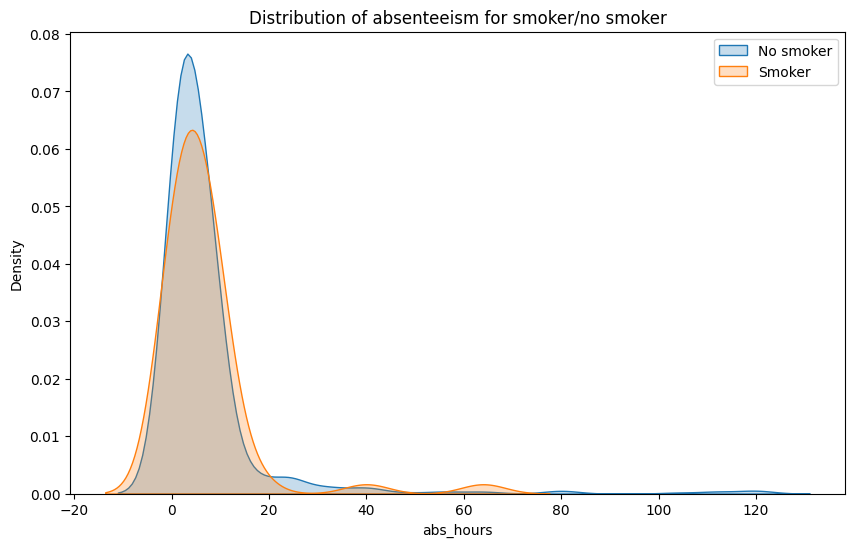

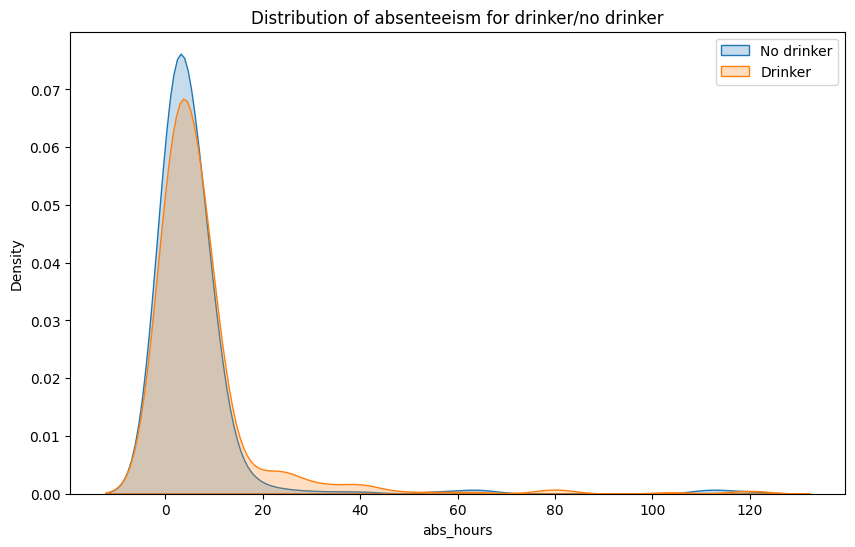

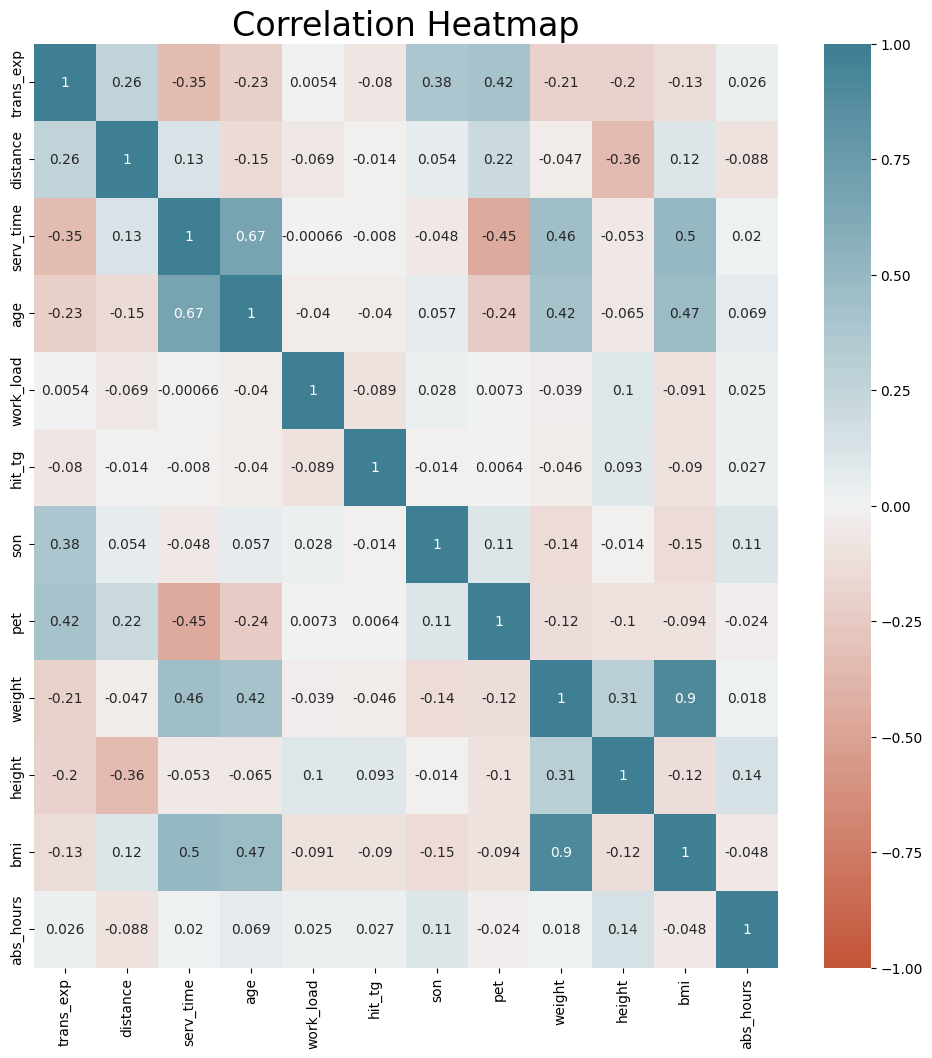

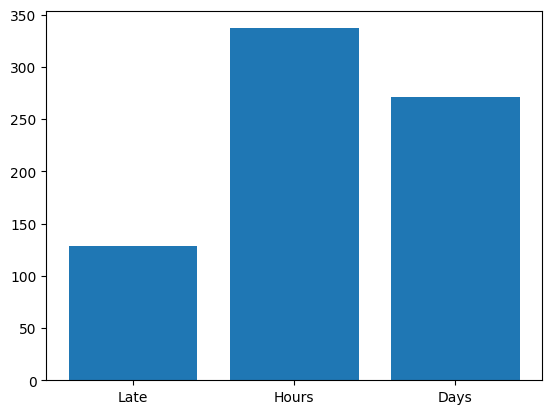

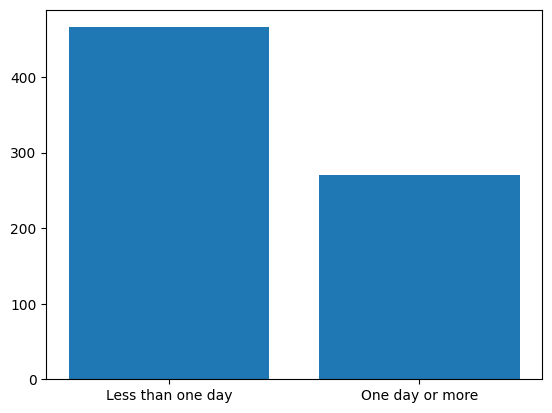

Veri setinde boş/kayıp değer yok.


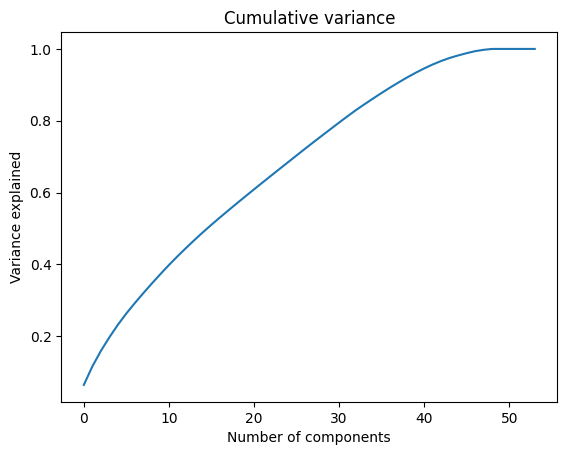

Basit eğitim setinin :
	 189 sayıda days değeri var.
	 236 sayıda hours değeri var.
	 90 sayıda late değeri var.
ROS eğitim setinin :
	 236 sayıda days değeri var.
	 236 sayıda hours değeri var.
	 236 sayıda late değeri var.
SMOTE eğitim setinin :
	 236 sayıda days değeri var.
	 236 sayıda hours değeri var.
	 236 sayıda late değeri var.
ADASYN eğitim setinin :
	 217 sayıda days değeri var.
	 236 sayıda hours değeri var.
	 244 sayıda late değeri var.
Entropi karar ağacı için en iyi parametre 0.68 skoruyla {'max_depth': np.int64(5)}
Gini karar ağacı için en iyi parametre 0.67 skoruyla {'max_depth': np.int64(8)}
Rastgele orman entropisi için en iyi parametre 0.76 skoruyla {'max_depth': np.int64(8)}
Gini rastgele orman entropisi için en iyi parametre 0.75 skoruyla {'max_depth': np.int64(6)}
KNN için en iyi parametre 0.73 skoruyla {'n_neighbors': np.int64(5)}
SVM için en iyi parametre 0.78 skoruyla {'C': np.float64(0.517947467923121)} 


,Accuracy,Precision,Sensitivity,F1 Score
Lojistik Regresyon,0.860360,0.817073,0.807229,0.812121
Ağaç Entropisi,0.792793,0.695122,0.730769,0.712500
Gini Ağacı,0.810811,0.719512,0.756410,0.737500
Orman Entropisi,0.855856,0.792683,0.812500,0.802469
Gini Ormanı,0.864865,0.841463,0.802326,0.821429
KNN,0.846847,0.768293,0.807692,0.787500
SVM,0.873874,0.951220,0.764706,0.847826
Naive Bayes,0.725225,0.718228,0.725225,0.715953
Yapay Sinir Ağları,0.837838,0.836377,0.837838,0.835932


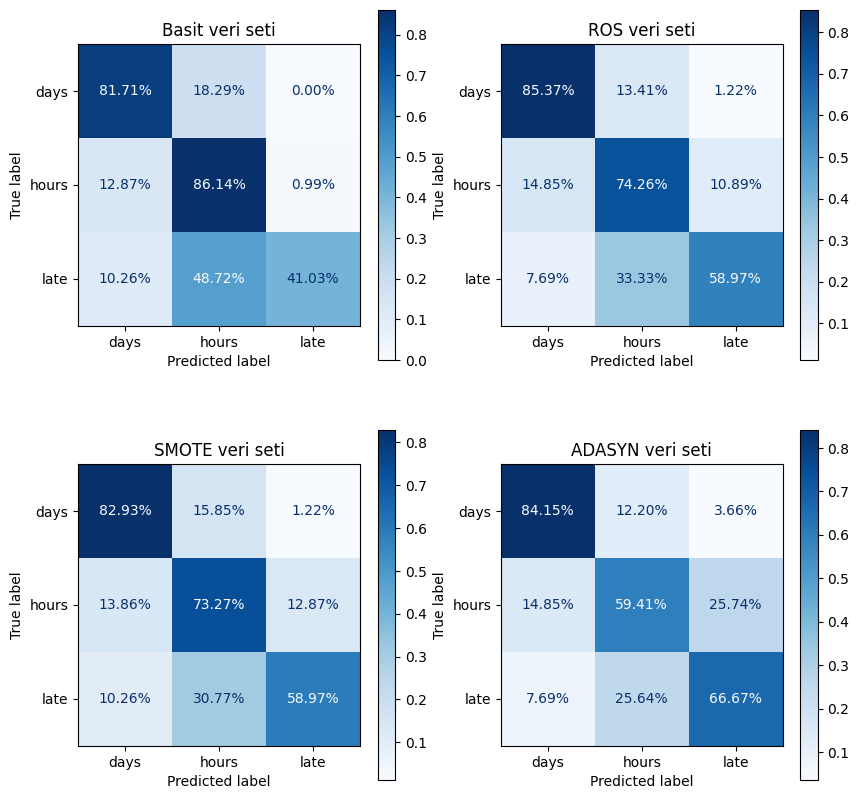

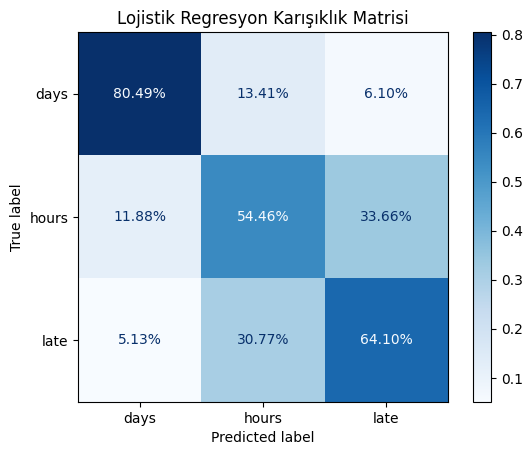

En iyi parametre 0.66 skoruyla {'max_depth': np.int64(5)}


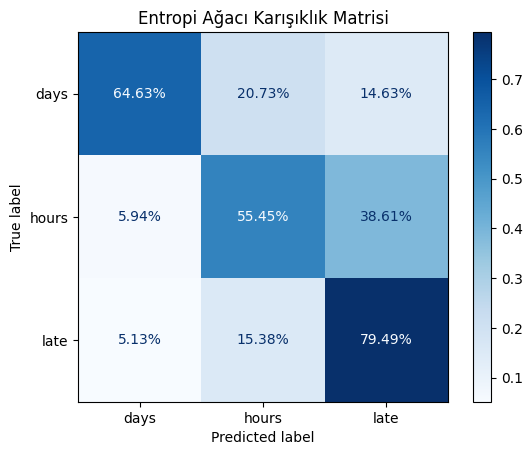

En iyi parametre 0.66 skoruyla {'max_depth': np.int64(4)} 


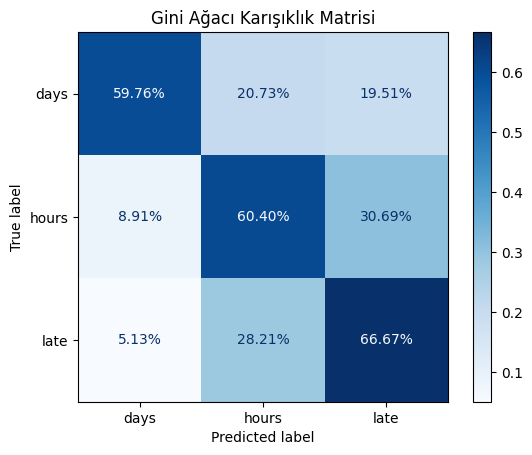

En iyi parametre 0.71 skoruyla {'max_depth': np.int64(9)} 


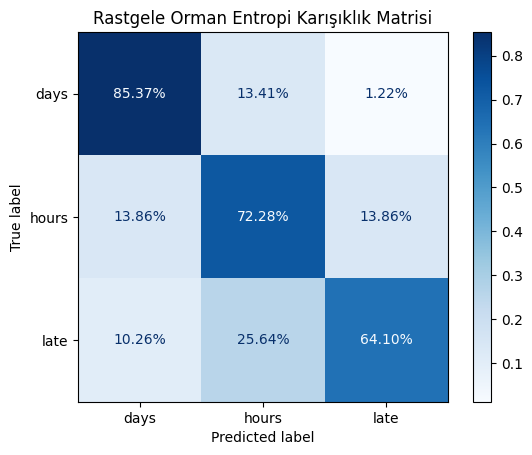

YSA için en iyi parametreler: {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'max_iter': 500}


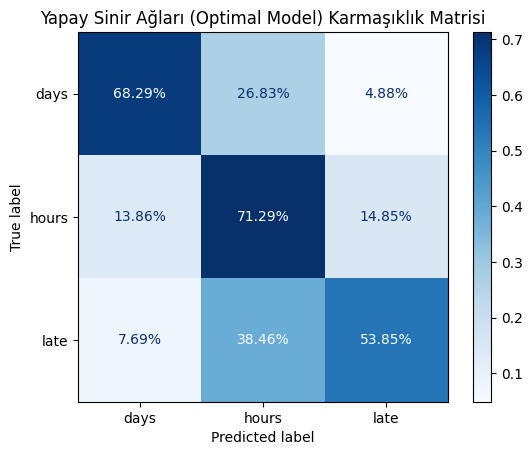

In [5]:
"""
========================================================================
  İşe Devamsızlık Tahmini - Makine Öğrenmesi Analizi
  Veri Seti: Absenteeism at Work (UCI ML Repository)
  Ders: Veri Bilimi Dönem Projesi
========================================================================
"""

# ===========================================================
# 1. KÜTÜPHANELERİN İÇE AKTARIMI
# ===========================================================
from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE , ADASYN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import calendar
from scipy import stats

# Sklearn - Ön işleme
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Sklearn - Modeller
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import validation_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Sklearn - Metrikler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(42)

# ===========================================================
# 2. VERİ YÜKLEME VE İLK İNCELEME
# ===========================================================


url = "https://raw.githubusercontent.com/Furkanaytu/Is_Devamsizligi_Tahmini/refs/heads/main/Absenteeism_at_work.csv"
# Ayırıcıyı ; olarak okumasını sağlayalım.
ds = pd.read_csv(url, sep=';')
print(f" Veri seti başarıyla yüklendi: {ds.shape[0]} satır, {ds.shape[1]} sütun")

# sütunların başında ve sonunda boşluk olma ihtimaline karşı temizliyoruz.
ds.columns = ds.columns.str.strip()

# Sütun isimlerini düzenleyelim.
ds = ds.rename(columns = {'ID' : 'id',
                          'Reason for absence': 'reason',
                          'Month of absence': 'month',
                          'Day of the week': 'day',
                          'Seasons' : 'season',
                          'Transportation expense': 'trans_exp',
                          'Distance from Residence to Work': 'distance',
                          'Service time': 'serv_time',
                          'Work load Average/day': 'work_load',
                          'Age' : 'age',
                          'Hit target': 'hit_tg',
                          'Son' : 'son',
                          'Disciplinary failure': 'disc_fail',
                          'Social drinker': 'drinker',
                          'Social smoker': 'smoker',
                          'Pet' : 'pet',
                          'Education' : 'education',
                          'Weight' : 'weight',
                          'Height' : 'height',
                          'Body mass index': 'bmi',
                          'Absenteeism time in hours': 'abs_hours'})

# Veri setinde boş/kayıp değer olup olmadığını kontrol edelim.
if ds.isnull().values.any():
    print("Veri setinde boş/kayıp değer var.")
else:
    print("Veri setinde boş/kayıp değer yok.")

# ===========================================================
# 3. VERİ ÖN İŞLEME
# ===========================================================

# Veri setini incelediğimizde month (ay) değeri 0 olan veriler görüyoruz.
# Ay değeri 1 ile 12 arasında olması gerektiği için bu verileri yoksayıyoruz.
ds = ds[ds['month'] != 0]

# Aynı şekilde veri setini incelediğmizde devamsızlık sebebi 0 olan (bilinmeyen)
# bazı veriler görüyoruz. Onlara da yakından baktığımızda bu verilerin devamsızlık saatinin de  neredeyse hepsinin 0 olduğunu görüyoruz.
# Muhtemelen bir saatin altındaki bazı işe geç kalmaları bu şekilde kayıt altına almışlar.
# Bu verileri de projeye dahil etmenin işe yarayacağını düşündüğüm için bu verileri silmiyoruz.

# Mevsim isimlerini düzenleyelim:
season_mapping = {1:'Summer', 2:'Autumn', 3:'Winter', 4:'Spring'}
ds['season_name'] = ds.season.map(season_mapping).astype('category')

# Ay isimlerini düzenleyelim:
ds['month_name'] =  ds['month'].apply(lambda x: calendar.month_abbr[x])

# Gün isimlerini düzenleyelim:
ds['day_name'] =  ds['day'].apply(lambda x: calendar.day_abbr[x-2])
# Takvime göre 0: Pazartesi ama bizim veri setimize göre 2: Pazartesi olduğu için x-2 yapıyoruz.

# Devamsızlığa sebep olan değerlerin isimlerini düzenleyelim.
reason_mapping = {
    0: 'Bilinmiyor / Mevcut değil',
    1: 'Belirli enfeksiyon ve parazit hastalıkları',
    2: 'Neoplazmalar (Tümörler)',
    3: 'Kan ve bağışıklık sistemi hastalıkları',
    4: 'Endokrin, beslenme ve metabolizma hastalıkları',
    5: 'Ruhsal ve davranışsal bozukluklar',
    6: 'Sinir sistemi hastalıkları',
    7: 'Göz ve göz ekleri hastalıkları',
    8: 'Kulak ve mastoid çıkıntı hastalıkları',
    9: 'Dolaşım sistemi hastalıkları',
    10: 'Solunum sistemi hastalıkları',
    11: 'Sindirim sistemi hastalıkları',
    12: 'Cilt ve cilt altı doku hastalıkları',
    13: 'Kas-iskelet sistemi ve bağ dokusu hastalıkları',
    14: 'Ürogenital sistem hastalıkları',
    15: 'Gebelik, doğum ve lohusalık dönemi',
    16: 'Perinatal dönemden kaynaklanan durumlar',
    17: 'Doğuştan gelen malformasyon ve kromozom anomalileri',
    18: 'Sınıflandırılmamış semptomlar ve anormal bulgular',
    19: 'Yaralanma, zehirlenme ve dış etken sonuçları',
    20: 'Hastalık ve ölümün dışsal nedenleri',
    21: 'Sağlık durumunu etkileyen faktörler ve sağlık hizmetleri',
    22: 'Hasta takibi',
    23: 'Tıbbi konsültasyon (Doktor görüşmesi)',
    24: 'Kan bağışı',
    25: 'Laboratuvar muayenesi / tetkik',
    26: 'Haksız/Gerekçesiz devamsızlık',
    27: 'Fizyoterapi',
    28: 'Diş muayenesi'
}
ds['reason_text'] = ds['reason'].map(reason_mapping)
ds['reason_text'] = ds['reason_text'].astype('category')

# Eğitim seviyelerini düzenleyelim:
education_mapping = {
    1: '1. High School',
    2: '2. Graduate',
    3: '3. Post Graduate',
    4: '4. Master & Doctor'
}
ds['education_detail'] = ds['education'].map(education_mapping)
ds['education_detail'] = ds['education_detail'].astype('category')

# sigara ve alkol kullananları bool tipinden düzenleyelim.
ds['smoker'] = ds['smoker'].astype('bool')
ds['drinker'] = ds['drinker'].astype('bool')
ds_explore = ds.copy()
ds = ds.drop(columns = {'reason','month','day','season','education'})
# ===========================================================
# 4. KEŞİFSEL VERİ ANALİZİ (EDA)
# ===========================================================

# Görselleştirme açısından faydalı olması için devamsızlık saatine göre durumları kategorize edelim.
def level(absh):
  if(absh < 2):
    lev = 'late'
  elif((absh >= 2) and (absh < 8)):
    lev = 'hours'
  elif(absh >= 8):
    lev = 'days'
  return lev

ds_explore['abs_lev'] = ds_explore['abs_hours'].apply(lambda x: level(x)).astype('category')

# Plt şeklinde devamsızlık saatlerini görselleştirelim.
bins = 40
fig, ax = plt.subplots()
ax.hist(ds_explore['abs_hours'], bins, rwidth=0.8, density = True)
ax.set_xlabel('Absenteeism time in hours')
ax.set_ylabel('Frequency')
plt.show()
# Aykırı değerlerin varlığı nedeniyle devamsızlık süresinin çarpık bir dağılım gösterdiğini görüyoruz.

# Boxplot şeklinde devamsızlık saatlerini görselleştirelim.
plt.boxplot(ds_explore['abs_hours'], widths = 0.5)
plt.ylabel('Absenteeism time in hours')
plt.xlabel('Boxplot')
plt.show()
# Devamsızlık süresi (saat) verisinde belirgin bir aykırı değer yoğunluğu mevcut.
# Özellikle alışılmadık derecede yüksek veya farklı olan birkaç gözlemin göze çarptığı görüyoruz.

# Bir haftadan (40 saatten) fazla süren devamsızlık sürelerinin sıklığını inceleyelim.
bins = 20
fig, ax = plt.subplots()
out = ds_explore[ds_explore['abs_hours'] > 40]
ax.hist(out['abs_hours'], bins, rwidth = 0.8, density = True)
ax.set_xlabel('Absenteeism time in hours')
ax.set_ylabel('Frequency')
plt.show()
# Veri setinin dengesiz olduğunu çok net görebiliyoruz. Sınıflara ait kayıt sayıları birbirinden çok farklı olabiliyor.
# Bu problemi ilerleyen aşamalarda oversampling (aşırı örnekleme) tekniği ile çözeceğim.

# Devamsızlığı gün bazında görselleştirelim.
time = ds_explore['abs_hours']
hours = np.count_nonzero(time < 8)
days = np.count_nonzero(time >= 8)
x = np.array(['Less than one day', 'One day or more'])
y = np.array([hours, days])
plt.bar(x, y)
plt.show()

# Devamsızlık nedeni (Reason for absence) özelliğinin çok önemli olduğunu biliyoruz.
# Her devamsızlık düzeyiyle en çok ilişkili olan nedenleri analiz edelim.

# Devamsızlık nedenleriyle birlikte devamsızlık saatlerini görselleştirelim.
sns.catplot(x = 'reason', y = 'abs_hours',
            data = ds_explore,
            height = 4,
            aspect = 2,
            jitter = '0.25',
            ).set_axis_labels("Reason of absence code", 'Absenteeism in hours')
# Başta belirttiğimiz devamsızlık nedenleri kodlamasını hatırlayacak olursak, Reason = 0 (yani Veri Yok/Bilinmiyor) olan devamsızlıkların neredeyse
# tamamının geç kalmalardan kaynaklandığını fark ediyoruz. Bunu zaten Veri Ön İşleme (Data Preprocessing) bölümünde fark etmiştik.
# Ayrıca, saatlik devamsızlık kodlarının ağırlıklı olarak 22 ile 28 arasında dağıldığını görüyoruz; bu kodlar herhangi bir Uluslararası Hastalık Sınıflandırması'na (ICD) karşılık gelmiyor.
# Yani bunlar hastalık veya yaralanma değil; sağlık kontrolleri, tıbbi konsültasyonlar ve benzeri durumlardır.
# Buna karşılık, bir gün veya daha uzun süren devamsızlıkların nedeninin genellikle ciddi bir sağlık problemi olduğu görüyoruz.
# Şimdi, her bir neden (Reason) için kayıtların devamsızlık seviyelerine göre nasıl dağıldığına bakalım.

# abs_lev(devamsızlık) durumunun late yani geç kalma olması durumunu inceleyelim.
reason_abs_lev = ds_explore.groupby('reason_text')['abs_lev'].value_counts().unstack().fillna(0).astype(int)
display(reason_abs_lev.sort_values(by=['late'], ascending=False).head())

# abs_lev(devamsızlık) durumunun hours yani 1-8 saat arası olması durumunu inceleyelim.
display(reason_abs_lev.sort_values(by=['hours'], ascending=False).head())

# abs_lev(devamsızlık) durumunun days yani 1 gün ve daha fazlası olması durumunu inceleyelim.
display(reason_abs_lev.sort_values(by = ['days'], ascending = False).head())

# HAFTANIN GÜNLERİ
# Günlere göre devamsızlık dağılımlarını inceleyelim.
sns.catplot(x = 'day_name', y = 'abs_hours',
            data = ds_explore,
            hue = 'day_name',
            palette = 'Set1',
            height = 4,
            aspect = 2,
            jitter = '0.25',
            ).set_axis_labels("Day of the week of absence", 'Absenteeism in hours')

days_abs_lev = ds_explore.groupby('day_name')['abs_lev'].value_counts().unstack().fillna(0).astype(int)
days_abs_lev

# AY
# Aylara göre devamsızlık dağılımlarını inceleyelim.
sns.catplot(x = 'month_name', y = 'abs_hours',
            data = ds_explore,
            hue = 'month_name',
            palette = 'Set1',
            height = 4,
            aspect = 2,
            jitter = '0.25',
            ).set_axis_labels("Month of absence", 'Absenteeism in hours')

# MEVSİM
# Mevsimlere göre devamsızlık dağılımlarını inceleyelim.
sns.catplot(x = 'season_name', y = 'abs_hours',
            data = ds_explore,
            hue = 'season_name',
            palette = 'Set1',
            height = 4,
            aspect = 2,
            jitter = '0.25',
            ).set_axis_labels("Season of absence", 'Absenteeism in hours')

# EĞİTİM DURUMU
# Eğitim durumuna göre devamsızlık dağılımlarını inceleyelim
sns.catplot(x = 'education_detail', y = 'abs_hours',
            data = ds_explore,
            hue = 'education_detail',
            palette = 'Set1',
            height = 4,
            aspect = 1.5).set_axis_labels("Education detail", 'Absenteeism in hours')

# ERKEK ÇOCUK
# Sahip olunan erkek çocuk sayısına göre devamsızlık dağılımlarını inceleyelim.
sns.catplot(x = 'son', y = 'abs_hours',
            data = ds_explore,
            hue = 'son',
            palette = 'Set1',
            height = 4,
            aspect = 1.5).set_axis_labels("Number of sons", 'Absenteeism in hours')

# EVCİL HAYVAN
# Sahip olunan evcil hayvan sayısına göre devamsızlık dağılımlarını inceleyelim.
sns.catplot(x = 'pet', y = 'abs_hours',
            data = ds_explore,
            hue = 'pet',
            palette = 'Set1',
            height = 4,
            aspect = 1.5).set_axis_labels("Number of pets", 'Absenteeism in hours')
plt.show()

# SİGARA İÇME
# Sigara içme durumuna göre devamsızlık dağılımlarını inceleyelim.
plt.figure(figsize=(10, 6))
abs_no_smoker = ds_explore[ds_explore['smoker'] == 0]['abs_hours']
abs_smoker = ds_explore[ds_explore['smoker'] == 1]['abs_hours']

sns.kdeplot(abs_no_smoker, fill=True, label='No smoker')
sns.kdeplot(abs_smoker, fill=True, label='Smoker')

plt.title('Distribution of absenteeism for smoker/no smoker')
plt.legend()
plt.show()

# ALKOL İÇME
# Alkol içme durumuna göre devamsızlık dağılımlarını inceleyelim.
plt.figure(figsize=(10, 6))
abs_no_drinker = ds_explore[ds_explore['drinker'] == 0]['abs_hours']
abs_drinker = ds_explore[ds_explore['drinker'] == 1]['abs_hours']

sns.kdeplot(abs_no_drinker, fill=True, label='No drinker')
sns.kdeplot(abs_drinker, fill=True, label='Drinker')

plt.title('Distribution of absenteeism for drinker/no drinker')
plt.legend()
plt.show()

# Correlation matrix (İlişki matrisi)
# Kategorik öznitelikleri(sütunları) çıkartıyorum ve normalizasyon yapıyorum.
ds_num = ds.drop(columns = ['id', 'disc_fail', 'drinker', 'smoker', 'season_name',
                            'month_name', 'day_name', 'reason_text', 'education_detail'])
ds_norm = (ds_num-ds_num.mean())/ds_num.std()
corr = ds_norm.corr()
plt.figure(figsize = (12,12))
sns.heatmap(corr, annot = True,
            vmin = -1, vmax = 1, center = 0,
            cmap = sns.diverging_palette(20, 220, n = 200))
plt.title('Correlation Heatmap', fontsize = 24)
plt.show()

# Isı haritasında (heatmap) bazı özellikler öne çıkıyor. Yakından baktığımızda; bmi, height (boy) ve weight (kilo) arasındaki,
# ayrıca distance (mesafe) ve transport expenses (ulaşım masrafları) arasındaki güçlü korelasyon, bazı özelliklerin veri setinden
# çıkarılabileceğini düşündürtüyor. Ayrıca Age (Yaş) ve Service time (Hizmet süresi) arasında da güçlü bir pozitif korelasyon var.
# Service time ile bmi (ve dolayısıyla Weight) arasında pozitif korelasyon mevcut.Transport expenses ile Service time arasında negatif korelasyon var.
# Service time ile Pet (evcil hayvan) sayısı arasında negatif korelasyon var.Transport expense ile evcil hayvan ve çocuk (son) sayısı arasında pozitif korelasyon var.
# Hiçbir özelliğin Absenteeism time in hours (saatlik devamsızlık süresi) ile güçlü bir negatif veya pozitif korelasyona sahip olmadığını fark ediyoruz.
# Daha derinlemesine inceleme yapmamız gerekiyor. Dahası, ısı haritasında kategorik verilerin dikkate alınmadığı açıkça görülüyor.
# Algoritmamızı daha çevik hale getirmek için boyut indirgemek (dimensionality reduction) istiyoruz; ancak bunu yaparken bilgi kaybına uğramamaya dikkat etmeliyiz.
# Bmi ve weight arasında 0.9 gibi çok güçlü bir korelasyon olduğunu görüyoruz. Nasıl hesaplandığını düşünürsek bu beklenen bir durumdu. BMI = weight/height^2
# İkisinden birini çıkararak bilgi kaybı yaşamayacağımızı söyleyebiliriz. Veri setimde height (boy) da bulunduğu için, weight (kilo) özniteliğini atmaya (drop) karar veriyorum.
ds = ds.drop(columns = 'weight')

# ===========================================================
# 5. VERİ HAZIRLAMA
# ===========================================================

# Devamsızlıkları görselleştirelim
time = ds['abs_hours']
late = np.count_nonzero(time < 2)
days = np.count_nonzero(time >= 8)
hours = np.count_nonzero(time >= 2) - days
x = np.array(['Late', 'Hours', 'Days'])
y = np.array([late, hours, days])
plt.bar(x, y)
plt.show()

# Veri setinin dağılımına baktığımızda, böyle bir ayrım uygulamanın modellerin en iyi performanslarını sergilemesine engel olabileceğini görebiliyoruz.
# Sadece iki sınıf kullanarak daha iyi bir performans (ve dolayısıyla daha fazla isabet oranı) elde edebiliriz.
# Bu doğrultuda ikili sınıflandırma (binary classification) uyguluyorum ve bir gün veya daha fazla süren devamsızlıkları tahmin etmeye çalışıyorum

# Devamsızlıkları görselleştirelim
time = ds['abs_hours']
less = np.count_nonzero(time < 8)
more = np.count_nonzero(time >= 8)
x = np.array(['Less than one day', 'One day or more'])
y = np.array([less, more])
plt.bar(x, y)
plt.show()

# abs_hour (devamsızlık saati) için etiket oluşturalım.

# Tüm sınıflar için sınıflandırma
def level(absh):
  if(absh < 2):
    lev = 'late'
  elif((absh >= 2) and (absh < 8)):
    lev = 'hours'
  elif(absh >= 8):
    lev = 'days'
  return lev

# binary sınıflar(ikili) için sınıflandırma.
def level_day(absh):
  if(absh < 8):
    day = 'less'
  elif(absh >= 8):
    day = 'more'
  return day

ds['abs_lev'] = ds['abs_hours'].apply(lambda x: level(x)).astype('category')
ds['abs_day'] = ds['abs_hours'].apply(lambda x: level_day(x)).astype('category')

X = ds.drop(columns = ['abs_lev', 'abs_day', 'abs_hours'])
y = ds['abs_lev']
y_day = ds['abs_day']
y_int = ds['abs_hours']
ds.head()

# Hedef değişken (target variable) haricinde, kullandığımız veri seti şu an 10 sayısal (numerical) ve 8 kategorik (categorical) özniteliğe sahip.
# Kategorik özniteliklerin 4 tanesi ikili (binary), 4 tanesi ise nominaldir.
# Nominal değerlerle çalışabilmek için yapılması gereken işlemler var. Orijinal veri seti label encoding (etiket kodlama) yöntemini uyguluyor; yani nominal değerler
# pozitif tam sayılar olarak kodlanmış.
# Buradaki problem, sayısal değerlerin bir sıralama gerektirmesidir; ancak açıkçası 'Yaz' mevsiminin 'Kış'tan daha büyük olduğunu veya 'Sinir sistemi hastalıkları'nın
# 'Solunum sistemi hastalıkları'ndan daha küçük olduğunu söyleyemeyiz. Bu teknik, değerlerin sıralanabildiği veya bir hiyerarşiye sahip olduğu durumlarda
# yararlı olabilir. Örneğin, Education (Eğitim) özniteliği 'Eğitim Seviyesi' olarak görülebilir ve bu durumda bir sıralama mantıklı olabilir.
# Fakat buradaki nominal özniteliklerin çoğu için durum böyle değil.
# Bu sorunun üstesinden gelmek için en yaygın kullanılan teknik one-hot encoding'dir. Her kategori değeri yeni bir sütuna dönüştürülür.
# İlgili değere 1,diğer her şeye 0 atanır.
# Bu yöntemi burada uygulamak, yaklaşık 50 yeni sütun eklemek anlamına geliyor (her kategorik niteliğin her bir seviyesi için bir sütun).
# Genel olarak bu durum göz ardı edilemez ve doğrudan yapılamaz.
# Bazı öznitelikleri çıkararak boyut indirgemeyi (reducing dimensionality) deneyebiliriz. Önceki incelemelerime dayanarak bazı verilerin gereksiz
# olabileceğini söyleyebilirim. Özellikle, devamsızlık yapılan ay (month of absence) bilgisinin devamsızlık süresiyle pek bağlantılı olmadığını gördük.
# Bu özniteliğin 12 yeni sütun ekleyeceği ve halihazırda mevsim (season) özniteliğine sahip olduğumuz gerçeğiyle, ayı analiz kapsamına almamaya karar veriyorum.

# 5.1 RELABELING (yeniden etiketleme)
#------------------------------------------------------
# LabelEncoder nesnesi, metin halindeki (kelime) etiketleri nasıl anlamlandıracağını (sayıya çevireceğini) bilir.

Z = X.copy()
label_encoder = LabelEncoder()

ylabel = label_encoder.fit_transform(y)
levels = label_encoder.inverse_transform(list(set(ylabel)))
ybin = label_encoder.fit_transform(y_day)
bin_levels = label_encoder.inverse_transform(list(set(ybin)))

# ONE HOT ENCODING
#------------------------------------------------------
# Yeni sütunları ekliyoruz.
#Z = pd.concat([Z,pd.get_dummies(Z['month_name'], prefix = 'month')], axis=1) | Ayı analiz kapsamına almıyoruz.
Z = pd.concat([Z,pd.get_dummies(Z['reason_text'], prefix = 'reason')], axis=1)
Z = pd.concat([Z,pd.get_dummies(Z['day_name'], prefix = 'day')], axis=1)
Z = pd.concat([Z,pd.get_dummies(Z['season_name'], prefix = 'season')], axis=1)
Z = pd.concat([Z,pd.get_dummies(Z['education_detail'], prefix = 'education')], axis=1)
# Eski nominal sütunları(değişkenleri) kaldırıyoruz.
Z.drop(['reason_text'],axis=1, inplace=True)
Z.drop(['month_name'],axis=1, inplace=True)
Z.drop(['day_name'],axis=1, inplace=True)
Z.drop(['season_name'],axis=1, inplace=True)
Z.drop(['education_detail'],axis=1, inplace=True)
Z.drop(['id'],axis=1, inplace=True)

# 5.2 TEMEL BİLEŞENLER ANALİZİ (PCA)
#------------------------------------------------------
# Temel bileşenler analizi (PCA), veri boyutluluğunu azaltmak için ortogonal (dik) dönüşüm kullanan istatistiksel bir prosedürdür.
# Bu işlem, değişkenlerin doğrusal bir dönüşümü yoluyla gerçekleşir; orijinal değişkenler yeni bir Kartezyen sisteme yansıtılır.
# Bu yeni sistemde, en büyük varyansa (değişkenliğe) sahip olan yeni değişken birinci eksene, varyans büyüklüğü açısından
# ikinci sırada olan yeni değişken ikinci eksene yansıtılır ve bu şekilde devam eder."

X_pca = Z.copy()
# Normalizasyon
X_pca_norm = (X_pca-X_pca.mean())/X_pca.std()
if X_pca_norm.isnull().values.any() :
  print("Veri setinde boş/kayıp değerler var.")
else :
  print("Veri setinde boş/kayıp değer yok.")

# Temel bileşenleri hesaplayalım
X_pca = PCA(random_state = SEED).fit(X_pca_norm)
cumvar = np.cumsum(X_pca.explained_variance_ratio_)
# Kümülatif varyansı görselleştirelim.
plt.plot(cumvar)
plt.title('Cumulative variance')
plt.xlabel('Number of components')
plt.ylabel('Variance explained')
plt.show()

cumvar[36] # 0.8923636610989951
# Kümülatif varyans grafiği, ilk 36 temel bileşeni (principal component) kullanarak varyansın yaklaşık %90'ını kapsayabileceğimizi gösteriyor.
# Bu nedenle onları kullanmaya karar veriyorum.

n_used = 36
X_pca = np.dot(X_pca_norm.values, X_pca.components_[:n_used,:].T)
X_pca = pd.DataFrame(X_pca, columns=["PC%d" % (x + 1) for x in range(n_used)])
X_pca.head()

# Şimdi veri setini iki alt kümeye ayırıyorum:
# Eğitim seti (Training set): Sınıflandırma modelini eğitmek için kullanılan etiketli veri nesneleri koleksiyonu.
# Test seti (Test set): Sınıflandırma modelini doğrulamak için kullanılan etiketli veri nesneleri koleksiyonu.
# Verilerin %70'ini eğitim seti, %30'unu ise test işlemleri için kullanıyorum.

X_train, X_test, y_train, y_test = train_test_split(X_pca, ylabel, test_size = 0.3, random_state = SEED, stratify = ylabel)
Xbin_train, Xbin_test, ybin_train, ybin_test = train_test_split(X_pca, ybin, test_size = 0.3, random_state = SEED, stratify = ybin)

# 5.3 AŞIRI ÖRNEKLEME (Oversampling)
# Daha önce tartışıldığı üzere, sınıflandırma kurgusunda veri seti düşük düzeyli devamsızlığa doğru büyük ölçüde eğilimlidir (skewed) ve sınıflarımız
# kuvvetli bir şekilde dengesizdir (unbalanced). Bu sorunu aşırı örnekleme (oversampling) ile çözebiliriz.
# Bunu yapmak için üç yaygın teknik bulunmaktadır:

# Rastgele Aşırı Örnekleme (Random Oversampling): En basit yöntemdir; az temsil edilen sınıflarda rastgele yeni örnekler oluşturur.

# SMOTE(Synthetic Minority Oversampling Technique)(Sentetik Azınlık Aşırı Örnekleme Tekniği): Veri setinden bir örnek alır ve onun (özellik uzayındaki)
# en yakın komşularını(k nearest neighbors) dikkate alır. Sentetik bir veri noktası oluşturmak için, bu komşulardan biri ile mevcut veri noktası arasındaki vektörü alır.
# Bu vektörü 0 ile 1 arasında rastgele bir sayı ile çarpar. Yeni, sentetik veri noktasını oluşturmak için bunu mevcut veri noktasına ekler.

# ADASYN(ADAptive SYNthetic sampling approach)(Uyarlamalı Sentetik Örnekleme Yaklaşımı): Bu algoritma, sınıflandırma sınırının önemini öğrenilmesi zor olan azınlık
# sınıflarına kaydırarak SMOTE metodolojisi üzerine inşa edilir. ADASYN, farklı azınlık sınıfı örnekleri için öğrenme zorluğu seviyelerine göre
# ağırlıklı bir dağılım kullanır; burada öğrenilmesi daha zor olan azınlık sınıfı örnekleri için daha fazla sentetik veri üretilir.

# RASTGELE AŞIRI ÖRNEKLEME, SMOTE VE ADSYN YÖNTEMLERİYLE YENİ VERİSETİ OLUŞTURALIM.
X_train_ROS, y_train_ROS = RandomOverSampler(random_state = SEED).fit_resample(X_train, y_train)
X_train_SMOTE, y_train_SMOTE = SMOTE(random_state = SEED).fit_resample(X_train, y_train)
X_train_ADASYN, y_train_ADASYN = ADASYN(random_state = SEED, sampling_strategy = 'not majority').fit_resample(X_train, y_train)

y_set = {'Basit': y_train, 'ROS': y_train_ROS, 'SMOTE': y_train_SMOTE, 'ADASYN': y_train_ADASYN}
for ys in y_set.keys():
  print( ys, 'eğitim setinin :')
  for i in set(ylabel):
          print('\t', np.count_nonzero(y_set[ys] == i), 'sayıda',levels[i], 'değeri var.')

# ===========================================================
# 6. SINIFLANDIRMA MODELLERİ
# ===========================================================
# Sınıflandırma; yeni bir gözlemin, kategori üyeliği bilinen gözlemlerden (veya örneklerden) oluşan bir eğitim setine dayanarak
# bir dizi kategoriden (alt popülasyonlardan) hangisine ait olduğunu belirleme problemidir.
# Burada en yaygın sınıflandırma algoritmalarını uyguluyorum ve performanslarını farklı metrikler kullanarak karşılaştıracağım:

# TP = Doğru Pozitif, TN = Doğru Negatif, FP = Yanlış Pozitif, FN = Yanlış Negatif olsun.
# Doğruluk(Accuracy) = TP+TN/(TP+TN+FP+FN)
# Kesinlik(Precision) = TP/(TP+FP)
# Duyarlılık(Sensitivity / Recall) = TP/(TP+FN)
# Özgüllük (Specificity) = TN/(TN+FP)
# F1 skoru (F1 Score) = 2 * [(Precision * Sensitivity)/(Precision + Sensitivity)]

# Tüm bu metrikler, ağırlıklı (weighted) versiyonları kullanılarak ikiden fazla sınıfa sahip konfigürasyonlara kolayca genelleştirilebilir.
# Çalışmanın büyük bir kısmı, farklı metriklerin sınırlarını ve özelliklerini belirlemekti. Üç sınıflı sınıflandırma için performans ölçütü
# olarak karışıklık matrisini (confusion matrix) de kullanıyorum.
# Önce İkili (Binary) Sınıflandırma ile başlıyorum ve ardından üç sınıf kullanarak daha spesifik sonuçlar elde etmeye çalışıyoruz."

# 6.1 Binary Sınıflandırma (Binary classification)
#------------------------------------------------------
# Burada iki sınıflı bir hedef kullanarak, devamsızlığın bir gün mü yoksa daha uzun mu süreceğini tahmin etmeye çalışıyorum.
binary_metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Sensitivity", "F1 Score"])

# LOJİSTİK REGRESYON (Logistic Regression)
#------------------------------------------------------
# Lojistik regresyon, belirli bir sınıfın veya olayın var olma olasılığını modellemek için kullanılan istatistiksel bir modeldir.
# Eğer sınıflar ikiliyse (binary), belirli bir örneğin ilgili kategoriye ait olma olasılığını şu şekilde hesaplayabiliriz:
# Y = 1 : p(x) = P(Y = 1 | X) olasılığının dağılımı:
# p(x) = [e^(beta0 + beta1*x)] / [(1 + e^(beta0 + beta1x))]

# p kadar değişken (feature) için genelleştirilmiş hali:
# p(x) = [e^(beta0 + beta1x1 + ... + betapxp)] / [(1 + e^(beta0 + beta1x1 + ... + betapxp))]

# Lojistik Regresyon
logistic = LogisticRegression(max_iter = 10000, random_state = SEED, solver = 'lbfgs')
logistic.fit(Xbin_train, ybin_train)
logistic_predict = logistic.predict(Xbin_test)
logi_acc = accuracy_score(logistic_predict, ybin_test)
logi_preci = precision_score(logistic_predict, ybin_test)
logi_sensitivity = recall_score(logistic_predict, ybin_test)
logi_f1 = f1_score(logistic_predict, ybin_test)
binary_metrics.loc["Lojistik Regresyon"] = [logi_acc,logi_preci,logi_sensitivity,logi_f1]

# KARAR AĞACI (Decision Tree)
#------------------------------------------------------
# Karar ağacı, sınıflandırma problemleri için oldukça yaygın bir modeldir (sınıflandırma ağacı olarak da adlandırılır).
# Bu bağlamda bir karar ağacı; yaprak düğümlerin (leaf nodes) sınıflandırmaları, dallanmaların (ramifications) ise bu sınıflandırmalara yol açan
# özellik setlerini temsil ettiği bir ağaç yapısını tanımlar. Sonuç olarak, her bir iç düğüm (internal node), alt düğümleriyle ilişkili sınıfların birleşiminden
# oluşan bir makro sınıftır.
# Birçok durumda, ağacın maksimum derinliğini belirlemek için bir durdurma kriteri (halting criterion) ve hatta budama kriteri (pruning criterion) tanımlamak faydalıdır. Bunun nedeni, bir ağacın artan derinliğinin (veya boyutunun) modelin başarısını doğrudan etkilememesidir. Aksine, ağaç boyutundaki aşırı büyüme, tahminlerin/sınıflandırmaların doğruluğu konusundaki faydalara kıyasla, hesaplama karmaşıklığında orantısız bir artışa yol açabilir.
# Algoritma, her adımda belirli metriklere göre öğe setini en iyi bölen değişkeni seçer. Ağacın inşasına rehberlik etmek için en çok
# kullanılan parametreler Gini indeksi ve Entropi sapmasıdır.

# Gini İndeksi (Gini Index) şu şekilde hesaplanır:
# GI(t) = 1 - sum(p(j|t)^2)  [j=1'den k'ya kadar]

# Entropi Sapması (Entropy Deviance) şu şekilde hesaplanır:
# Entropy(t) = - sum(p(j|t) * log2(p(j|t)))  [j=1'den k'ya kadar]

# Burada 't' düğümü temsil ederken, p(j|t) ise t düğümündeki j sınıfının bağıl frekansıdır.

# Karar Ağacı

depth = np.arange(4, 20) # Ağaçlar ve ormanlar için derinlik ayarı
parameters = {'max_depth': depth}

# Entropi kriteri
tree_Entropy = GridSearchCV(tree.DecisionTreeClassifier(criterion = 'entropy', random_state = SEED), parameters, scoring = 'f1')
tree_Entropy = tree_Entropy.fit(Xbin_train, ybin_train)
tree_Entropy_pred = tree_Entropy.predict(Xbin_test)
tree_acc = accuracy_score(tree_Entropy_pred, ybin_test)
tree_preci = precision_score(tree_Entropy_pred, ybin_test)
tree_sensitivity = recall_score(tree_Entropy_pred, ybin_test)
tree_f1 = f1_score(tree_Entropy_pred, ybin_test)
binary_metrics.loc["Ağaç Entropisi"] = [tree_acc, tree_preci, tree_sensitivity, tree_f1]
print("Entropi karar ağacı için en iyi parametre %0.2f skoruyla %s" % (tree_Entropy.best_score_, tree_Entropy.best_params_))

# Gini kriteri
tree_Gini = GridSearchCV(tree.DecisionTreeClassifier(criterion = 'gini', random_state = SEED), parameters, scoring = 'f1')
tree_Gini = tree_Gini.fit(Xbin_train, ybin_train)
tree_Gini_pred = tree_Gini.predict(Xbin_test)
tree_acc = accuracy_score(tree_Gini_pred, ybin_test)
tree_preci = precision_score(tree_Gini_pred, ybin_test)
tree_sensitivity = recall_score(tree_Gini_pred, ybin_test)
tree_f1 = f1_score(tree_Gini_pred, ybin_test)
binary_metrics.loc["Gini Ağacı"] = [tree_acc, tree_preci, tree_sensitivity, tree_f1]
print("Gini karar ağacı için en iyi parametre %0.2f skoruyla %s" % (tree_Gini.best_score_, tree_Gini.best_params_))

# RASTGELE ORMAN (Random Forest)
#------------------------------------------------------
# İsminden de anlaşılabileceği üzere, Rastgele Orman sınıflandırıcısı, birkaç karar ağacının aynı anda paralel olarak kullanılmasıyla elde edilir.
# Genel fikir, makul ölçüde çok sayıda karar ağacını farklı alt örneklere (subsample) eğitmek ve ardından etikete karar vermeyi çoğunluğa (oy birliğine) bırakmaktır.
# Rastgele ormanlar, karar ağaçlarına kıyasla eğitim setindeki aşırı öğrenme (overfitting) sorununu en aza indiren bir çözümdür.
# Karar ağaçlarında olduğu gibi, burada da hem Gini hem de Entropi kriterlerini kullanacağız.

# Rastgele Orman
parameters = {'max_depth': depth}

# Entropi Kriteri
forest_Entropy = GridSearchCV(RandomForestClassifier(n_estimators = 100, criterion = 'entropy',
                                                     random_state = SEED), parameters, scoring = 'f1')
forest_Entropy = forest_Entropy.fit(Xbin_train, ybin_train)
forest_Entropy_pred = forest_Entropy.predict(Xbin_test)
forest_acc = accuracy_score(forest_Entropy_pred, ybin_test)
forest_preci = precision_score(forest_Entropy_pred, ybin_test)
forest_sensitivity = recall_score(forest_Entropy_pred, ybin_test)
forest_f1 = f1_score(forest_Entropy_pred, ybin_test)
binary_metrics.loc["Orman Entropisi"] = [forest_acc,forest_preci,forest_sensitivity,forest_f1]
print("Rastgele orman entropisi için en iyi parametre %0.2f skoruyla %s" % (forest_Entropy.best_score_, forest_Entropy.best_params_))

# Gini Kriteri
forest_Gini = GridSearchCV(RandomForestClassifier(n_estimators = 100, criterion = 'gini',
                                                  random_state = SEED), parameters, scoring = 'f1')
forest_Gini = forest_Gini.fit(Xbin_train, ybin_train)
forest_Gini_pred = forest_Gini.predict(Xbin_test)
forest_acc = accuracy_score(forest_Gini_pred, ybin_test)
forest_preci = precision_score(forest_Gini_pred, ybin_test)
forest_sensitivity = recall_score(forest_Gini_pred, ybin_test)
forest_f1 = f1_score(forest_Gini_pred, ybin_test)
binary_metrics.loc["Gini Ormanı"] = [forest_acc,forest_preci,forest_sensitivity,forest_f1]
print("Gini rastgele orman entropisi için en iyi parametre %0.2f skoruyla %s" % (forest_Gini.best_score_, forest_Gini.best_params_))

# K-EN YAKIN KOMŞU (K-Nearest Neighbours)
#------------------------------------------------------
# K-en yakın komşu (KNN), bir nesneyi, kendisine en yakın olan diğer nesnelerin özelliklerine dayanarak sınıflandırmak ve örüntüleri tanımak için
# kullanılan bir algoritmadır. Makine öğrenmesinde kullanılan en basit algoritmalardan biridir. Yeni bir nokta, kendisine en yakın olan veri
# noktalarının benzerliklerine göre kategorize edilir. K parametresinin seçimi verilerin özelliklerine bağlıdır. Genel olarak, K değeri arttıkça
# sınıflandırmayı bozan gürültü azalır, ancak sınıf seçim kriteri daha kaba hale gelir. Bu seçim sezgisel (heuristic) tekniklerle yapılabilir.
# Doğru bir model oluşturmanın en iyi yolu, uygun K değerini seçmek için çapraz doğrulama (cross validation) kullanmaktır.

# KNN
neigh = np.arange(2, 20)
parameters = {'n_neighbors': neigh}
knn = GridSearchCV(KNeighborsClassifier(), parameters, scoring = 'f1')
knn = knn.fit(Xbin_train, ybin_train)
knn_predict = knn.predict(Xbin_test)
neigh_acc = accuracy_score(knn_predict, ybin_test)
neigh_preci = precision_score(knn_predict, ybin_test)
neigh_sensitivity = recall_score(knn_predict, ybin_test)
neigh_f1 = f1_score(knn_predict, ybin_test)
binary_metrics.loc["KNN"] = [neigh_acc,neigh_preci,neigh_sensitivity,neigh_f1]
print("KNN için en iyi parametre %0.2f skoruyla %s" % (knn.best_score_, knn.best_params_))

# DESTEK VEKTÖR MAKİNESİ (Support Vector Machine)
#------------------------------------------------------
# Temel Destek Vektör Makinesi (SVM) modeli doğrusaldır: En yakın noktaların karar sınırına olan uzaklığının maksimize edildiği,
# iki sınıfın noktaları arasındaki optimal hiper düzlemi (hyperplane) bulur. Açıktır ki, doğrusal bir ayrım yaygın değildir ve SVM genelleştirilebilir.
# Bu genelleme, destek vektör makinesine uygulanacak doğrusal olmayan bir Çekirdek (Kernel) fonksiyonu seçilerek yapılabilir.

# Doğrusal destek vektör makinesi genellikle doğrusal çekirdek olarak şunu kullanır: k(xi, xj) = xi . xj

# Muhtemelen en yaygın doğrusal olmayan alternatif ise Radyal tabanlı çekirdektir (Radial basis kernel): k(xi, xj) = exp(-gamma * ||xi - xj||^2)

# Burada seçilmesi gereken bir parametre olan gamma > 0 bulunur. Bu, aslında kütüphanedeki varsayılan çekirdek fonksiyonudur.
# Temel olarak çekirdek, veriyi sınıfların doğrusal olarak ayrılabileceği başka bir uzaya haritalarken; orijinal uzayda sınır genel olarak doğrusal olmayacaktır.

# SVM
Cs = np.logspace(-2, 2, 8)
parameters = {'C': Cs}
svm_mod = GridSearchCV(svm.SVC(gamma = 'auto', kernel = "rbf", random_state = SEED), parameters, scoring = 'f1')
svm_mod = svm_mod.fit(Xbin_train, ybin_train)
svm_mod_predict = svm_mod.predict(Xbin_test)
svm_acc = accuracy_score(svm_mod_predict, ybin_test)
svm_preci = precision_score(svm_mod_predict, ybin_test)
svm_sensitivity = recall_score(svm_mod_predict, ybin_test)
svm_f1 = f1_score(svm_mod_predict, ybin_test)
binary_metrics.loc["SVM"] = [svm_acc,svm_preci,svm_sensitivity,svm_f1]
print("SVM için en iyi parametre %0.2f skoruyla %s " % (svm_mod.best_score_, svm_mod.best_params_))

# NAIVE BAYES
#------------------------------------------------------
# Naive Bayes, Bayes Teoremi'ne dayanan, özellikle sınıflandırma (classification) problemlerini çözmek için kullanılan, olasılık tabanlı,
# basit ama oldukça etkili bir makine öğrenmesi algoritmasıdır. "Üretken" (generative) bir öğrenme algoritmasıdır, yani belirli bir sınıfa ait
# verilerin dağılımını modeller. Algoritmanın en önemli özelliği, özelliklerin (features) birbirinden bağımsız olduğunu varsaymasıdır.
# Yani, bir özelliğin varlığı veya değeri, diğer bir özelliğin varlığıyla ilişkisiz kabul edilir.
# (Gerçek hayatta bu varsayım nadiren doğru olsa da algoritma yine de iyi çalışır).

nb_model = GaussianNB()
nb_model.fit(Xbin_train, ybin_train)
nb_pred = nb_model.predict(Xbin_test)
nb_acc = accuracy_score(ybin_test, nb_pred)
nb_preci = precision_score(ybin_test, nb_pred, average='weighted')
nb_sensitivity = recall_score(ybin_test, nb_pred, average='weighted')
nb_f1 = f1_score(ybin_test, nb_pred, average='weighted')
binary_metrics.loc["Naive Bayes"] = [nb_acc, nb_preci, nb_sensitivity, nb_f1]

# YAPAY SİNİR AĞLARI
#------------------------------------------------------
# Yapay Sinir Ağları (YSA), insan beyninin biyolojik sinir sisteminden (nöron yapısı ve çalışma prensipleri) esinlenerek geliştirilen,
# verilerdeki karmaşık ilişkileri öğrenmeyi ve modellemeyi amaçlayan bir yapay zeka ve makine öğrenmesi yöntemidir.
# Bu yöntem, büyük miktardaki veriyi işleyerek örüntüleri tanıyan, sınıflandırma yapan veya tahminleme gerçekleştirebilen çok katmanlı,
# birbirine bağlı düğümlerden (yapay nöronlar) oluşan bir bilgi işlem teknolojisidir.

mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED)
mlp_model.fit(Xbin_train, ybin_train)
mlp_pred = mlp_model.predict(Xbin_test)
mlp_acc = accuracy_score(ybin_test, mlp_pred)
mlp_preci = precision_score(ybin_test, mlp_pred, average='weighted')
mlp_sensitivity = recall_score(ybin_test, mlp_pred, average='weighted')
mlp_f1 = f1_score(ybin_test, mlp_pred, average='weighted')
binary_metrics.loc["Yapay Sinir Ağları"] = [mlp_acc, mlp_preci, mlp_sensitivity, mlp_f1]
display(binary_metrics)

# Bu yapılandırma ayarlarını kullanarak tüm modeller oldukça iyi performans göstermektedir. Bu parametre seçimiyle kesinlik (precision) ve
# doğruluk (accuracy) seviyelerinin yüksek olduğunu, duyarlılığın (sensitivity) ise biraz daha düşük kaldığını görüyoruz.
# Diğer tüm metrikleri göz önünde bulunduran bileşik bir ölçüt olduğu için, karşılaştırma aracı olarak genellikle F1 Skorunu kullanmak daha uygundur.

# Genel olarak, bu metrikler arasında bir denge (trade-off) kurabiliriz: Yanlış pozitifleri mi yoksa yanlış negatifleri mi tercih ettiğimize bağlı olarak
# bunlardan birine öncelik verecek şekilde sınıflandırıcı parametrelerini seçebiliriz. Örneğin, bir şirket, olasılık çok düşük olsa bile birinin
# devamsızlık yapma riskini hesaba katmak isteyebilir. Tüm bunlar, doğrulama (validation) adımında değerlendirilerek kolayca gerçekleştirilebilir.

# 5.2 ÜÇ SEVİYELİ SINIFLANDIRMA (Three-levels classification)
#------------------------------------------------------
# Şimdi daha derine iniyoruz: Devamsızlık seviyelerini 'geç kalma' (late), 'saatlik' (hours) ve 'günlük' (days) olmak üzere üç sınıf kullanarak tahmin etmeye çalışıyorum.
# Bu sınıfların, sadece uygulama senaryosu düşünülerek seçildikleri için kuvvetli bir şekilde dengesiz (unbalanced) olduğunu unutmamak gerekir.
# Bunları dengelemek için yukarıda tanımlanan modellerden bazılarını seçmem gerekiyor. En iyisini belirlemek için, hepsini Rastgele Orman (Random Forest) ve denemeye değer bulduğum için YSA
# sınıflandırıcılarını kullanarak değerlendirmek ve ardından en iyi performans göstereni seçmek istiyorum.

# Rastgele orman sınıflandırması (Random forest classifier)

# Basit veri seti (Simple dataset)
simple_forest = RandomForestClassifier(random_state = SEED, max_depth = 10).fit(X_train, y_train)
simple_pred = simple_forest.predict(X_test)

# Rastgele aşırı örnekleme (Random Oversampling)
ros_forest = RandomForestClassifier(random_state = SEED, max_depth = 10).fit(X_train_ROS, y_train_ROS)
random_over_pred = ros_forest.predict(X_test)

#SMOTE
SMOTE_forest = RandomForestClassifier(random_state = SEED, max_depth = 10).fit(X_train_SMOTE, y_train_SMOTE)
SMOTE_pred = SMOTE_forest.predict(X_test)

#ADASYN
ADASYN_forest = RandomForestClassifier(random_state = SEED, max_depth = 10).fit(X_train_ADASYN, y_train_ADASYN)
ADASYN_pred = ADASYN_forest.predict(X_test)

#Performans

# Basit veri seti metrikleri:
simple_pred_accuracy = accuracy_score(y_test, simple_pred)
simple_pred_precision = precision_score(y_test, simple_pred, average = 'weighted')
simple_pred_sensitivity = recall_score(y_test, simple_pred, average = 'weighted')
simple_pred_f1 = f1_score(y_test, simple_pred, average = 'weighted')

# Rastgele aşırı örnekleme metrikleri:
rnd_sampler_accuracy = accuracy_score(y_test, random_over_pred)
rnd_sampler_precision = precision_score(y_test,random_over_pred, average = 'weighted')
rnd_sampler_sensitivity = recall_score(y_test,random_over_pred, average = 'weighted')
rnd_sampler_f1 = f1_score(y_test,random_over_pred, average = 'weighted')

# SMOTE metrikleri:
SMOTE_accuracy = accuracy_score(y_test, SMOTE_pred)
SMOTE_precision = precision_score(y_test, SMOTE_pred, average = 'weighted')
SMOTE_sensitivity = recall_score(y_test, SMOTE_pred, average = 'weighted')
SMOTE_f1 = f1_score(y_test, SMOTE_pred, average = 'weighted')

# ADASYN metrikleri:
ADASYN_accuracy = accuracy_score(y_test, ADASYN_pred)
ADASYN_precision = precision_score(y_test, ADASYN_pred, average = 'weighted')
ADASYN_sensitivity = recall_score(y_test, ADASYN_pred, average = 'weighted')
ADASYN_f1 = f1_score(y_test, ADASYN_pred, average = 'weighted')

# Metrikler
metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Sensitivity", "F1 Score"])
metrics.loc["Basit veri seti"] = [simple_pred_accuracy,simple_pred_precision,simple_pred_sensitivity,simple_pred_f1]
metrics.loc["Rastgele aşırı örnekleme"] = [rnd_sampler_accuracy,rnd_sampler_precision,rnd_sampler_sensitivity,rnd_sampler_f1]
metrics.loc["SMOTE"] = [SMOTE_accuracy,SMOTE_precision,SMOTE_sensitivity,SMOTE_f1]
metrics.loc["ADASYN"] = [ADASYN_accuracy,ADASYN_precision,ADASYN_sensitivity,ADASYN_f1]
metrics

fig, ((simple, ros), (smote, adasyn)) = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))

ConfusionMatrixDisplay.from_estimator(simple_forest, X_test, y_test,
                                      display_labels=levels,
                                      cmap=plt.cm.Blues,
                                      values_format='0.2%',
                                      normalize='true',
                                      ax=simple)
simple.set_title('Basit veri seti')
ConfusionMatrixDisplay.from_estimator(ros_forest, X_test, y_test,
                                      display_labels=levels,
                                      cmap=plt.cm.Blues,
                                      values_format='0.2%',
                                      normalize='true',
                                      ax=ros)
ros.set_title('ROS veri seti')
ConfusionMatrixDisplay.from_estimator(SMOTE_forest, X_test, y_test,
                                      display_labels=levels,
                                      cmap=plt.cm.Blues,
                                      values_format='0.2%',
                                      normalize='true',
                                      ax=smote)
smote.set_title('SMOTE veri seti')
ConfusionMatrixDisplay.from_estimator(ADASYN_forest, X_test, y_test,
                                      display_labels=levels,
                                      cmap=plt.cm.Blues,
                                      values_format='0.2%',
                                      normalize='true',
                                      ax=adasyn)
adasyn.set_title('ADASYN veri seti')
plt.show()
# ROS veri seti teoride iyi gözükse de mevcut verileri kopyaladığı için overfitting(aşırı öğrenme) riskini arttırıyor.
# Biz modelin ezberlemesini değil öğrenmesini amaçlıyoruz, bu yüzden ADASYN ya da SMOTE veri setini seçeceğim.
# Late (geç kalma) durumunda ADASYN daha tutarlı bir sonuç gösterse de karmaşıklık açısından en iyisi SMOTE seti gibi görünüyor. Onu kullanacağım.
#------------------------------------------------------
# SMOTE
#------------------------------------------------------

X_val = X_train
y_val = y_train
X_train = X_train_SMOTE
y_train = y_train_SMOTE

classification_metrics = pd.DataFrame(columns=["Accuracy", "Precision", "Sensitivity", "F1 Score"])

# LOJİSTİK REGRESYON
logistic = LogisticRegression(max_iter = 10000, random_state = SEED, solver = 'lbfgs').fit(X_train, y_train)
logistic_predict = logistic.predict(X_test)

# Metrikler
logi_acc = accuracy_score(logistic_predict, y_test)
logi_preci = precision_score(logistic_predict, y_test, average = 'weighted')
logi_sensitivity = recall_score(logistic_predict, y_test, average = 'weighted')
logi_f1 = f1_score(logistic_predict, y_test, average = 'weighted')

# Karmaşıklık Matrisi

classification_metrics.loc["Logistic regression"] = [logi_acc,logi_preci,logi_sensitivity,logi_f1]
ConfusionMatrixDisplay.from_estimator(
    logistic,
    X_test,
    y_test,
    display_labels=levels,
    cmap=plt.cm.Blues,
    values_format='0.2%',
    normalize='true'
)
plt.title("Lojistik Regresyon Karışıklık Matrisi")
plt.show()

# En iyi parametreleri değerlendirelim
depth = np.arange(4, 20)
parameters = {'max_depth': depth}
clf = GridSearchCV(tree.DecisionTreeClassifier(criterion = 'entropy', random_state = SEED), parameters, scoring = 'f1_weighted')
clf = clf.fit(X_val, y_val)
opt_depth = clf.best_params_['max_depth']
print("En iyi parametre %0.2f skoruyla %s" % (clf.best_score_, clf.best_params_))

# KARAR AĞACI : Entropi
tree_Entropy = tree.DecisionTreeClassifier(max_depth = opt_depth, criterion = 'entropy', random_state = SEED)
tree_Entropy = tree_Entropy.fit(X_train, y_train)
tree_Entropy_pred = tree_Entropy.predict(X_test)

# Metrikler
tree_acc = accuracy_score(tree_Entropy_pred, y_test)
tree_preci = precision_score(tree_Entropy_pred, y_test, average = 'weighted')
tree_sensitivity = recall_score(tree_Entropy_pred, y_test, average = 'weighted')
tree_f1 = f1_score(tree_Entropy_pred, y_test, average = 'weighted')

# Karmaşıklık Matrisi

classification_metrics.loc["Tree Entropy"] = [tree_acc, tree_preci, tree_sensitivity, tree_f1]
ConfusionMatrixDisplay.from_estimator(
    tree_Entropy,
    X_test,
    y_test,
    display_labels=levels,
    cmap=plt.cm.Blues,
    values_format='0.2%',
    normalize='true'
)
plt.title("Entropi Ağacı Karışıklık Matrisi")
plt.show()

# En iyi parametreleri değerlendirelim
depth = np.arange(4, 20)
parameters = {'max_depth': depth}
clf = GridSearchCV(tree.DecisionTreeClassifier(criterion = 'gini', random_state = SEED), parameters, scoring = 'f1_weighted')
clf = clf.fit(X_val, y_val)
opt_depth = clf.best_params_['max_depth']
print("En iyi parametre %0.2f skoruyla %s " % (clf.best_score_, clf.best_params_))

# KARAR AĞACI : Gini
tree_Gini = tree.DecisionTreeClassifier(max_depth = opt_depth, criterion = 'gini', random_state = SEED)
tree_Gini = tree_Gini.fit(X_train, y_train)
tree_Gini_pred = tree_Gini.predict(X_test)

# Metrikler
tree_acc = accuracy_score(tree_Gini_pred, y_test)
tree_preci = precision_score(tree_Gini_pred, y_test, average = 'weighted')
tree_sensitivity = recall_score(tree_Gini_pred, y_test, average = 'weighted')
tree_f1 = f1_score(tree_Gini_pred, y_test, average = 'weighted')

# Karmaşıklık Matrisi

classification_metrics.loc["Tree Gini"] = [tree_acc, tree_preci, tree_sensitivity, tree_f1]
ConfusionMatrixDisplay.from_estimator(
    tree_Gini,
    X_test,
    y_test,
    display_labels=levels,
    cmap=plt.cm.Blues,
    values_format='0.2%',
    normalize='true'
)
plt.title("Gini Ağacı Karışıklık Matrisi")
plt.show()

# En iyi parametreleri değerlendirelim
depth = np.arange(4, 20)
parameters = {'max_depth': depth}
clf = GridSearchCV(RandomForestClassifier(criterion = 'entropy', n_estimators = 200, random_state = SEED,
                                          ), parameters, scoring = 'f1_weighted')
clf = clf.fit(X_val, y_val)
opt_depth = clf.best_params_['max_depth']
print("En iyi parametre %0.2f skoruyla %s " % (clf.best_score_, clf.best_params_))

# RASTGELE ORMAN - Entropi kriteri
forest_Entropy = RandomForestClassifier(max_depth = opt_depth, criterion = 'entropy', n_estimators = 200, random_state = SEED)
forest_Entropy = forest_Entropy.fit(X_train, y_train)
forest_Entropy_pred = forest_Entropy.predict(X_test)

# Metrikler
forest_acc = accuracy_score(forest_Entropy_pred, y_test)
forest_preci = precision_score(forest_Entropy_pred, y_test, average = 'weighted')
forest_sensitivity = recall_score(forest_Entropy_pred, y_test, average = 'weighted')
forest_f1 = f1_score(forest_Entropy_pred, y_test, average = 'weighted')

# Karmaşıklık Matrisi

classification_metrics.loc["Random Forest Entropy"] = [forest_acc,forest_preci,forest_sensitivity,forest_f1]
ConfusionMatrixDisplay.from_estimator(
    forest_Entropy,
    X_test,
    y_test,
    display_labels=levels,
    cmap=plt.cm.Blues,
    values_format='0.2%',
    normalize='true'
)
plt.title("Rastgele Orman Entropi Karışıklık Matrisi")
plt.show()

# YAPAY SİNİR AĞLARI

mlp_parameters = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [500]
}
mlp_grid = GridSearchCV(
    MLPClassifier(random_state=SEED),
    mlp_parameters,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)
mlp_grid.fit(X_train, y_train)
print("YSA için en iyi parametreler: %s" % mlp_grid.best_params_)

mlp_model = mlp_grid.best_estimator_

mlp_pred = mlp_model.predict(X_test)

# Metrikler
mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_preci = precision_score(y_test, mlp_pred, average='weighted')
mlp_sensitivity = recall_score(y_test, mlp_pred, average='weighted')
mlp_f1 = f1_score(y_test, mlp_pred, average='weighted')

# Karmaşıklık Matrisi

classification_metrics.loc["YSA (Artificial Neural Network)"] = [mlp_acc, mlp_preci, mlp_sensitivity, mlp_f1]
ConfusionMatrixDisplay.from_estimator(
    mlp_model,
    X_test,
    y_test,
    display_labels=levels,
    cmap=plt.cm.Blues,
    values_format='0.2%',
    normalize='true'
)
plt.title("Yapay Sinir Ağları (Optimal Model) Karmaşıklık Matrisi")
plt.show()